# Deteccion de Árboles

<h2>Importante</h2>

Este notebook de Python ha sido desarrollado únicamente con fines educativos y de aprendizaje personal. No tiene propósitos comerciales ni de lucro.

El objetivo de este proyecto es aprender y explorar las capacidades de:
- YOLO (You Only Look Once) para detección de objetos en tiempo real
- Roboflow como plataforma para gestión y procesamiento de datasets de visión computacional
- Técnicas de detección de objetos y segmentación usando modelos de deep learning
- Implementación práctica de modelos de visión computacional

Este trabajo forma parte de un proceso de aprendizaje personal para comprender mejor las tecnologías de computer vision y sus aplicaciones.

In [1]:
# 1. CONFIGURACION GENERAL

import os
import random
import torch
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from torchinfo import summary
import pandas as pd
import numpy as np

DATASET_PATH = os.getcwd() + "/data"
MODEL_SIZE = "n"
data_yaml = os.path.join(DATASET_PATH, "data.yaml")

# Configurar dispositivo
device = 0 if torch.cuda.is_available() and torch.cuda.device_count() > 0 else "cpu"
print(f"Usando: {'GPU' if device == 0 else 'CPU'}")
print(f"Dataset: {os.path.exists(data_yaml)}")

Usando: GPU
Dataset: True


In [2]:
# 2. CARGAR O CONTINUAR MODELO

model_path = f"modelo_yolo12{MODEL_SIZE}.pt"
base_model = f"yolo12{MODEL_SIZE}.pt"

# Verificar si tenemos modelo previo entrenado
if os.path.exists(model_path):
    print(f"Continuando entrenamiento: {model_path}")
    model = YOLO(model_path)
    is_pretrained = False
else:
    print(f"Iniciando con modelo base: {base_model}")
    model = YOLO(base_model)
    is_pretrained = True

summary(model)

Iniciando con modelo base: yolo12n.pt


Layer (type:depth-idx)                                            Param #
YOLO                                                              --
├─DetectionModel: 1-1                                             --
│    └─Sequential: 2-1                                            --
│    │    └─Conv: 3-1                                             (464)
│    │    └─Conv: 3-2                                             (4,672)
│    │    └─C3k2: 3-3                                             (6,640)
│    │    └─Conv: 3-4                                             (36,992)
│    │    └─C3k2: 3-5                                             (26,080)
│    │    └─Conv: 3-6                                             (147,712)
│    │    └─A2C2f: 3-7                                            (181,120)
│    │    └─Conv: 3-8                                             (295,424)
│    │    └─A2C2f: 3-9                                            (689,920)
│    │    └─Upsample: 3-10                   

In [3]:
# 3. ENTRENAMIENTO

results = model.train(
    data=data_yaml,
    epochs=20,
    patience=8,
    lr0=1e-5,
    lrf=5e-6,
    momentum=0.937,
    weight_decay=0.001,
    warmup_epochs=5.0,
    imgsz=640,
    batch=10,  # tamaño de batch
    device=device,
    project="modelos",
    name="yolo12_arbol",
    save=True,
    save_period=10,
    plots=True,
    val=True,
    cos_lr=True,
    amp=False,  # Deshabilitar para evitar problemas con libreria
    exist_ok=True,
    seed=32,
    multi_scale=True,
    freeze=6,
    pretrained=is_pretrained,  # Solo si es modelo base
    verbose=True,
)

# Guardar modelo personalizado
best_model_path = "modelos/yolo12_arbol/weights/best.pt"
if os.path.exists(best_model_path):
    import shutil

    shutil.copy2(best_model_path, model_path)
    print(f"Modelo guardado: {model_path}")

Ultralytics 8.3.201  Python-3.10.16 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080 Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=c:\Users\MIJAIL\Desktop\Aprendiendo_todo\YOLO_NEW\YOLO_DET\tree1/data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=6, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=5e-06, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=True, name=yolo12_arbol, nbs=64, nms=False, opset=None, optimize=False, optimize

In [4]:
# 4. CARGAR MEJOR MODELO

if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    print(f"Usando: {best_model_path}")
else:
    best_model = model
    print("Usando modelo actual")

summary(best_model)

Usando: modelos/yolo12_arbol/weights/best.pt


Layer (type:depth-idx)                                            Param #
YOLO                                                              --
├─DetectionModel: 1-1                                             --
│    └─Sequential: 2-1                                            --
│    │    └─Conv: 3-1                                             (464)
│    │    └─Conv: 3-2                                             (4,672)
│    │    └─C3k2: 3-3                                             (6,640)
│    │    └─Conv: 3-4                                             (36,992)
│    │    └─C3k2: 3-5                                             (26,080)
│    │    └─Conv: 3-6                                             (147,712)
│    │    └─A2C2f: 3-7                                            (180,864)
│    │    └─Conv: 3-8                                             (295,424)
│    │    └─A2C2f: 3-9                                            (689,408)
│    │    └─Upsample: 3-10                   

In [5]:
# 5. VALIDACIÓN

try:
    valid_results = best_model.val(
        data=data_yaml, split="val", device=device, verbose=False
    )
    test_results = best_model.val(
        data=data_yaml, split="test", device=device, verbose=False
    )

    print(
        f"VALID - mAP50: {valid_results.box.map50:.4f}, mAP50-95: {valid_results.box.map:.4f}"
    )
    print(
        f"TEST  - mAP50: {test_results.box.map50:.4f}, mAP50-95: {test_results.box.map:.4f}"
    )
except Exception as e:
    print(f"Error en validación: {e}")

Ultralytics 8.3.201  Python-3.10.16 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080 Laptop GPU, 8192MiB)
YOLOv12n summary (fused): 159 layers, 2,556,923 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 192.534.9 MB/s, size: 39.1 KB)
val: Scanning C:\Users\MIJAIL\Desktop\Aprendiendo_todo\YOLO_NEW\YOLO_DET\tree1\data\valid\labels.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 111.5Kit/s 0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 306, len(boxes) = 13063. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 2.0it/s 7.0s0.2s
                   all        223      13063      0.928      0.924       0.94      0.573
Speed: 1.1ms preprocess, 5.6ms inference, 0.0ms loss,

In [6]:
# 6. FUNCIÓN PARA DETECCIONES CON UMBRAL

import pandas as pd


def detectar_objetos(ruta_imagen, umbral_confianza=0.1, mostrar=True):
    """
    Detectar objetos con umbral personalizable y visualización limpia

    Args:
        ruta_imagen: Ruta a la imagen
        umbral_confianza: Umbral mínimo de confianza (0.1 = 10%)
        mostrar: Mostrar imagen con detecciones

    Returns:
        DataFrame con todas las detecciones
    """
    if not os.path.exists(ruta_imagen):
        print(f"No existe: {ruta_imagen}")
        return None

    # Predicción con umbral bajo para capturar más detecciones
    results = best_model(
        ruta_imagen, device=device, verbose=False, conf=umbral_confianza
    )
    result = results[0]

    # Crear DataFrame con todas las detecciones
    detecciones_data = []

    if len(result.boxes) > 0:
        for i, box in enumerate(result.boxes):
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            coords = box.xyxy[0].tolist()  # [x1, y1, x2, y2]

            detecciones_data.append(
                {
                    "imagen": os.path.basename(ruta_imagen),
                    "deteccion_id": i + 1,
                    "confianza": round(conf, 3),
                    "x1": round(coords[0], 1),
                    "y1": round(coords[1], 1),
                    "x2": round(coords[2], 1),
                    "y2": round(coords[3], 1),
                    "ancho": round(coords[2] - coords[0], 1),
                    "alto": round(coords[3] - coords[1], 1),
                }
            )

    df_detecciones = pd.DataFrame(detecciones_data)

    # Mostrar información
    print(f"\nImagen: {os.path.basename(ruta_imagen)}")
    print(f"Detecciones totales: {len(df_detecciones)}")

    if len(df_detecciones) > 0:
        print(f"Confianza promedio: {df_detecciones['confianza'].mean():.3f}")
        print(f"Confianza máxima: {df_detecciones['confianza'].max():.3f}")
        print(f"Confianza mínima: {df_detecciones['confianza'].min():.3f}")

    # Visualización limpia
    if mostrar and len(df_detecciones) > 0:
        img = cv2.imread(ruta_imagen)
        img_clean = img.copy()

        # Dibujar solo rectángulos azules con confianza
        for _, det in df_detecciones.iterrows():
            x1, y1, x2, y2 = (
                int(det["x1"]),
                int(det["y1"]),
                int(det["x2"]),
                int(det["y2"]),
            )
            conf = det["confianza"]

            # Rectángulo azul
            cv2.rectangle(img_clean, (x1, y1), (x2, y2), (255, 0, 0), 2)

            # Solo texto de confianza con 2 decimales
            label = f"{conf:.2f}"

            # Fondo para el texto
            (text_width, text_height), _ = cv2.getTextSize(
                label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
            )
            cv2.rectangle(
                img_clean,
                (x1, y1 - text_height - 10),
                (x1 + text_width, y1),
                (255, 0, 0),
                -1,
            )

            # Texto blanco
            cv2.putText(
                img_clean,
                label,
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2,
            )

        # Mostrar imagen limpia
        img_rgb = cv2.cvtColor(img_clean, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 8))
        plt.imshow(img_rgb)
        plt.title(f"Detecciones: {os.path.basename(ruta_imagen)}")
        plt.axis("off")
        plt.show()

        # # Guardar resultado
        # output = f"limpio_{os.path.basename(ruta_imagen)}"
        # cv2.imwrite(output, img_clean)
        # print(f"Imagen guardada: {output}")

    return df_detecciones

Usando umbral de confianza: 0.1

Imagen: st3_815_image_3_5_jpg.rf.8c37da50c10715e3f5e19b895fed0519.jpg
Detecciones totales: 183
Confianza promedio: 0.634
Confianza máxima: 0.760
Confianza mínima: 0.104


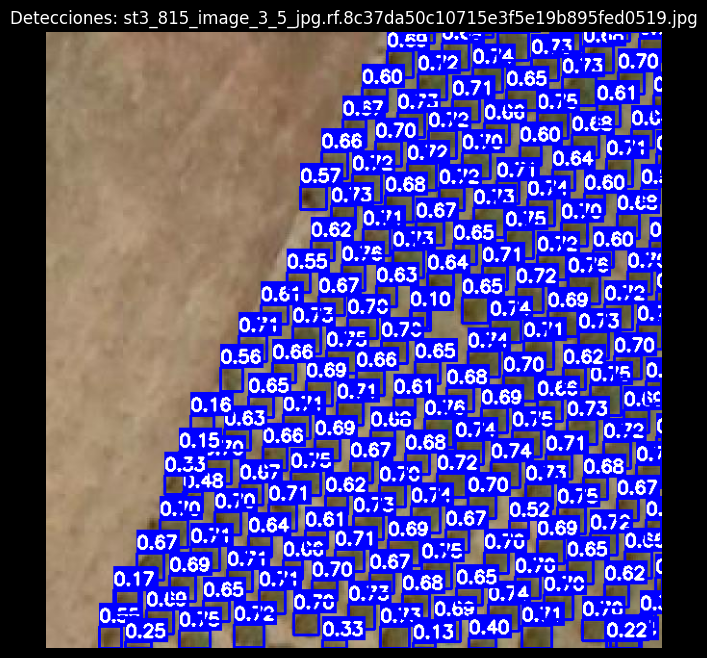


Imagen: sa18_51_image_5_1_jpg.rf.e2b50804aeef5717eb0ab1cbce684167.jpg
Detecciones totales: 16
Confianza promedio: 0.429
Confianza máxima: 0.808
Confianza mínima: 0.102


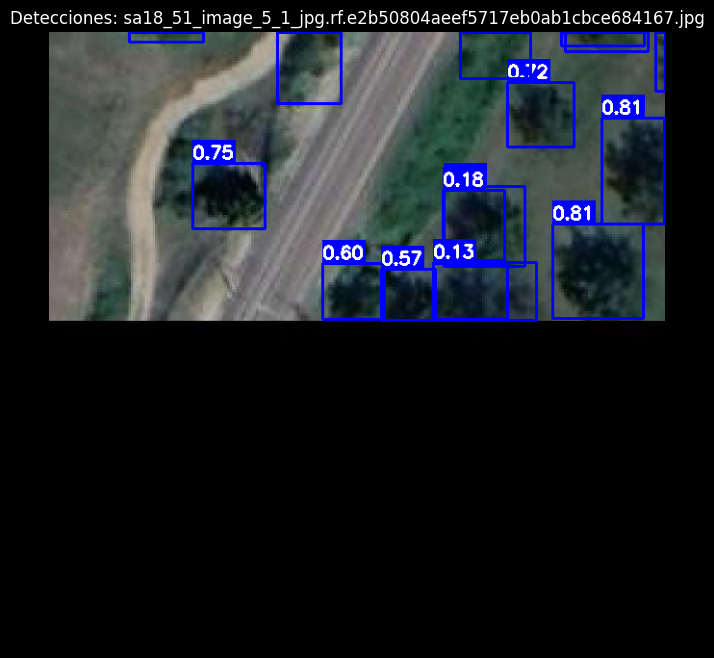

Imágenes procesadas: 2
Detecciones totales: 199


In [7]:
# 7. PREDICCIONES EN TEST - UMBRAL BAJO

# parametro test - umbral
umbral_test = 0.10

test_images_path = os.path.join(DATASET_PATH, "test", "images")
if os.path.exists(test_images_path):
    test_images = [
        f
        for f in os.listdir(test_images_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    if test_images:
        selected = random.sample(test_images, min(2, len(test_images)))

        # NOTA: Probar con umbral bajo para ver más detecciones
        umbral = umbral_test  # confianza minima
        print(f"Usando umbral de confianza: {umbral}")

        todas_detecciones = []

        for img_name in selected:
            img_path = os.path.join(test_images_path, img_name)
            df_det = detectar_objetos(img_path, umbral_confianza=umbral, mostrar=True)

            if df_det is not None and len(df_det) > 0:
                todas_detecciones.append(df_det)

        # Combinar todas las detecciones en uno solo
        if todas_detecciones:
            df_completo = pd.concat(todas_detecciones, ignore_index=True)
            print(f"Imágenes procesadas: {len(selected)}")
            print(f"Detecciones totales: {len(df_completo)}")
    else:
        print("No hay imágenes en test")
else:
    print("No existe carpeta test/images")

In [8]:
# Ver detecciones totales
df_completo

,imagen,deteccion_id,confianza,x1,y1,x2,y2,ancho,alto
0,st3_815_image_3_5_jpg.rf.8c37da50c10715e3f5e19...,1,0.760,393.6,401.8,423.6,431.4,30.0,29.6
1,st3_815_image_3_5_jpg.rf.8c37da50c10715e3f5e19...,2,0.757,542.0,253.2,575.4,282.9,33.4,29.7
2,st3_815_image_3_5_jpg.rf.8c37da50c10715e3f5e19...,3,0.755,307.2,241.8,331.5,268.5,24.3,26.7
3,st3_815_image_3_5_jpg.rf.8c37da50c10715e3f5e19...,4,0.754,484.6,413.1,514.3,441.9,29.7,28.8
4,st3_815_image_3_5_jpg.rf.8c37da50c10715e3f5e19...,5,0.752,477.8,205.3,506.4,235.5,28.6,30.2
...,...,...,...,...,...,...,...,...,...
194,sa18_51_image_5_1_jpg.rf.e2b50804aeef5717eb0ab...,12,0.166,399.6,240.9,476.1,298.9,76.5,58.1
195,sa18_51_image_5_1_jpg.rf.e2b50804aeef5717eb0ab...,13,0.153,83.5,0.0,160.7,10.9,77.1,10.9
196,sa18_51_image_5_1_jpg.rf.e2b50804aeef5717eb0ab...,14,0.152,532.6,0.0,618.6,14.2,86.0,14.2
197,sa18_51_image_5_1_jpg.rf.e2b50804aeef5717eb0ab...,15,0.127,399.9,239.5,506.4,299.4,106.5,59.9


Usando umbral de confianza: 0.4

Imagen: a10_05_05_jpg.rf.70d6115bb451e127ab4655cb18d1aa3a.jpg
Detecciones totales: 116
Confianza promedio: 0.647
Confianza máxima: 0.835
Confianza mínima: 0.408


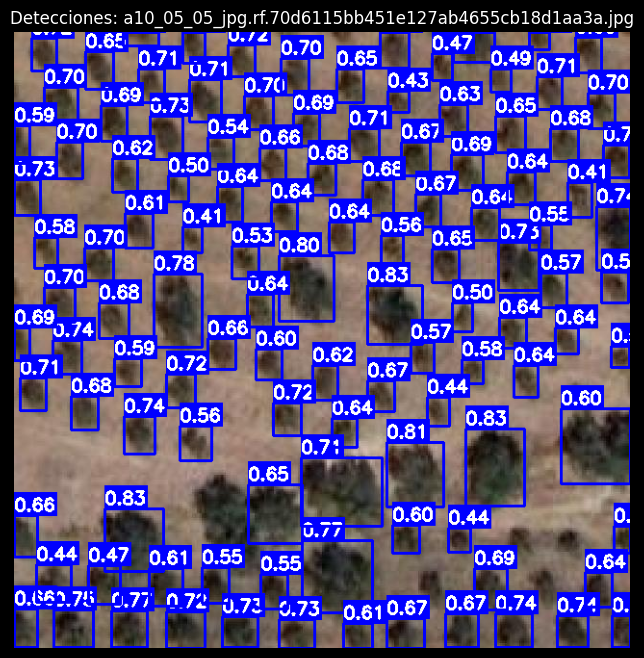


Imagen: sa24_395_image_3_5_jpg.rf.56fe4e96a2468a440a9cce420c178a87.jpg
Detecciones totales: 16
Confianza promedio: 0.677
Confianza máxima: 0.791
Confianza mínima: 0.438


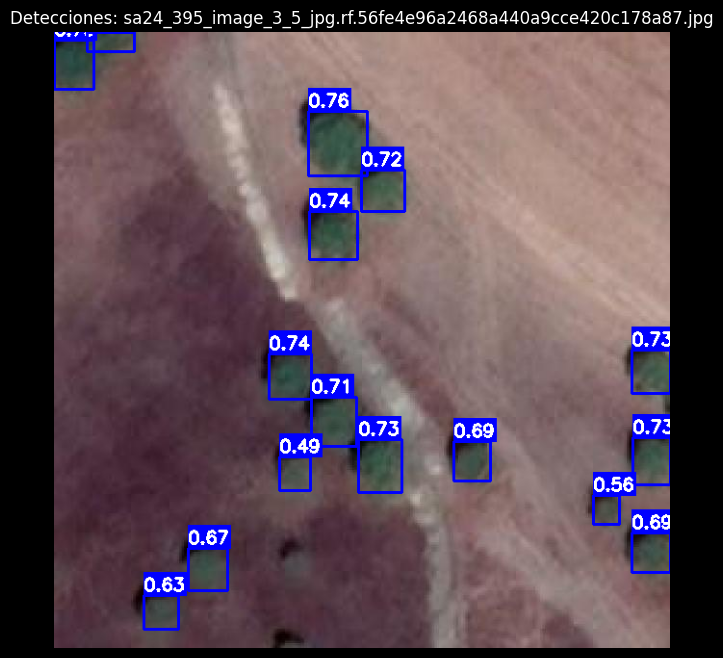

Imágenes procesadas: 2
Detecciones totales: 132


In [9]:
# 7. PREDICCIONES EN TEST - UMBRAL ALTO

# parametro test - umbral
umbral_test = 0.40

test_images_path = os.path.join(DATASET_PATH, "test", "images")
if os.path.exists(test_images_path):
    test_images = [
        f
        for f in os.listdir(test_images_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    if test_images:
        selected = random.sample(test_images, min(2, len(test_images)))

        # NOTA: Probar con umbral bajo para ver más detecciones
        umbral = umbral_test  # confianza minima
        print(f"Usando umbral de confianza: {umbral}")

        todas_detecciones = []

        for img_name in selected:
            img_path = os.path.join(test_images_path, img_name)
            df_det = detectar_objetos(img_path, umbral_confianza=umbral, mostrar=True)

            if df_det is not None and len(df_det) > 0:
                todas_detecciones.append(df_det)

        # Combinar todas las detecciones en uno solo
        if todas_detecciones:
            df_completo = pd.concat(todas_detecciones, ignore_index=True)
            print(f"Imágenes procesadas: {len(selected)}")
            print(f"Detecciones totales: {len(df_completo)}")
    else:
        print("No hay imágenes en test")
else:
    print("No existe carpeta test/images")

In [10]:
# Ver detecciones totales
df_completo

,imagen,deteccion_id,confianza,x1,y1,x2,y2,ancho,alto
0,a10_05_05_jpg.rf.70d6115bb451e127ab4655cb18d1a...,1,0.835,94.0,495.5,155.7,560.9,61.8,65.4
1,a10_05_05_jpg.rf.70d6115bb451e127ab4655cb18d1a...,2,0.828,469.7,412.3,530.7,492.1,61.1,79.8
2,a10_05_05_jpg.rf.70d6115bb451e127ab4655cb18d1a...,3,0.828,367.9,263.3,424.9,324.4,57.0,61.1
3,a10_05_05_jpg.rf.70d6115bb451e127ab4655cb18d1a...,4,0.808,387.9,426.2,446.3,493.6,58.5,67.4
4,a10_05_05_jpg.rf.70d6115bb451e127ab4655cb18d1a...,5,0.803,275.7,232.7,332.4,300.9,56.7,68.2
...,...,...,...,...,...,...,...,...,...
127,sa24_395_image_3_5_jpg.rf.56fe4e96a2468a440a9c...,12,0.665,139.4,536.9,180.0,580.6,40.7,43.6
128,sa24_395_image_3_5_jpg.rf.56fe4e96a2468a440a9c...,13,0.630,93.0,585.8,129.7,620.4,36.7,34.6
129,sa24_395_image_3_5_jpg.rf.56fe4e96a2468a440a9c...,14,0.556,560.4,481.8,587.3,511.3,26.9,29.6
130,sa24_395_image_3_5_jpg.rf.56fe4e96a2468a440a9c...,15,0.494,234.8,441.6,266.7,476.6,31.9,35.1


Encontradas 3 imágenes:
  - input_tree1.jpg
  - input_tree2.jpg
  - input_tree3.jpg

Procesando con umbral mínimo: 0.1

Imagen: input_tree1.jpg
Detecciones totales: 48
Confianza promedio: 0.718
Confianza máxima: 0.865
Confianza mínima: 0.172


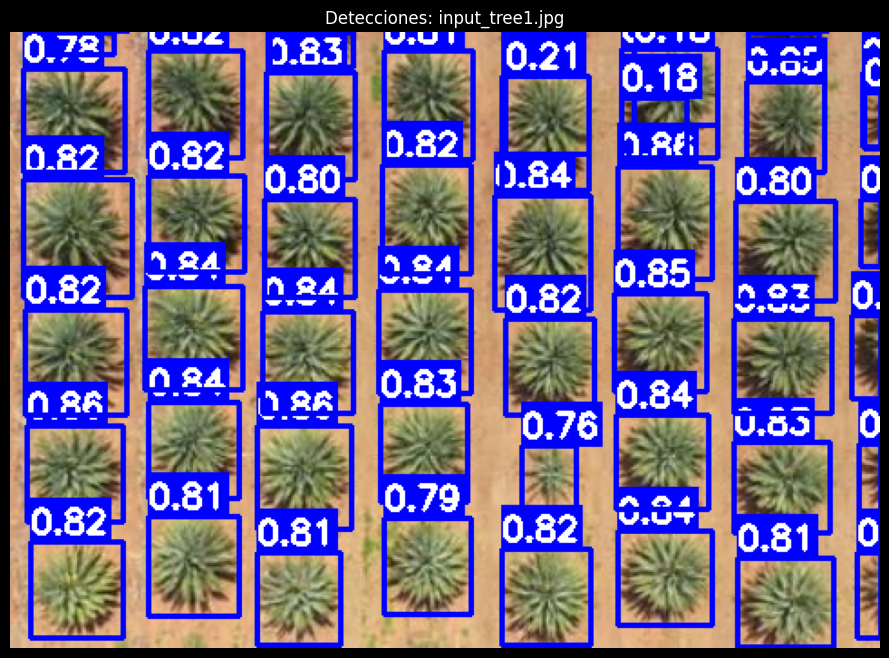

Detecciones por niveles de confianza:
nivel_confianza
Muy Alta (70%+)    35
Alta (50-70%)       7
Baja (0-30%)        4
Media (30-50%)      2
Name: count, dtype: int64

Imagen: input_tree2.jpg
Detecciones totales: 300
Confianza promedio: 0.254
Confianza máxima: 0.694
Confianza mínima: 0.107


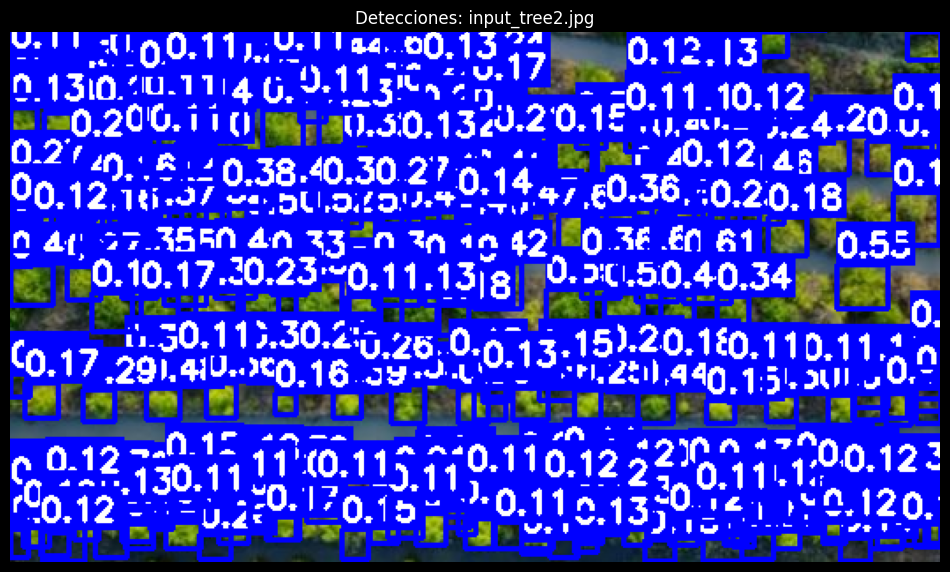

Detecciones por niveles de confianza:
nivel_confianza
Baja (0-30%)       204
Media (30-50%)      80
Alta (50-70%)       16
Muy Alta (70%+)      0
Name: count, dtype: int64

Imagen: input_tree3.jpg
Detecciones totales: 56
Confianza promedio: 0.410
Confianza máxima: 0.792
Confianza mínima: 0.113


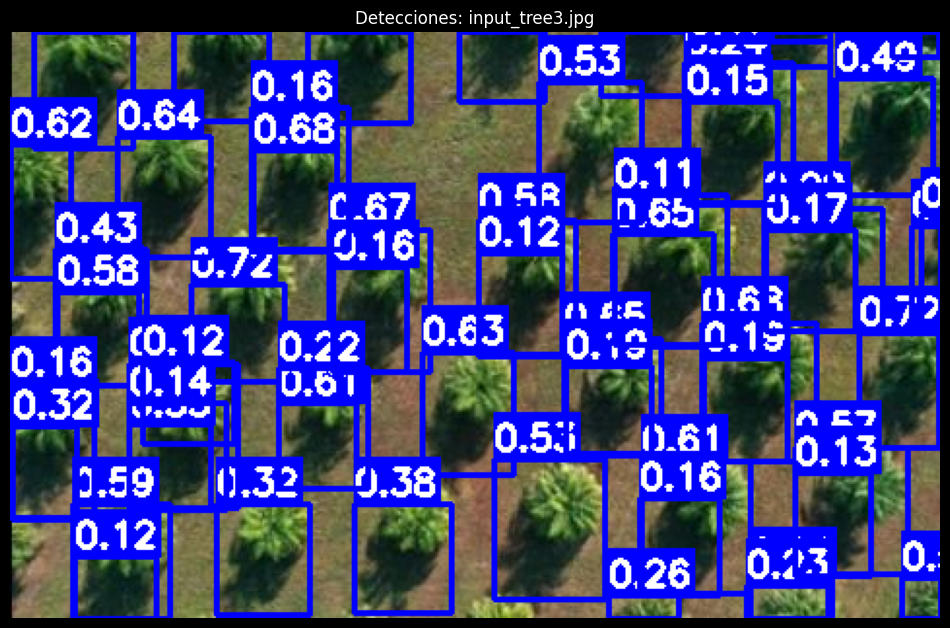

Detecciones por niveles de confianza:
nivel_confianza
Baja (0-30%)       25
Alta (50-70%)      20
Media (30-50%)      6
Muy Alta (70%+)     5
Name: count, dtype: int64

--- REPORTE FINAL ---
Total detecciones: 404
Confianza promedio: 0.331

Detecciones por imagen:
                 count   mean    max
imagen                              
input_tree1.jpg     48  0.718  0.865
input_tree2.jpg    300  0.254  0.694
input_tree3.jpg     56  0.410  0.792


In [11]:
# 8. BUSCAR Y PROBAR MODELO - UMBRAL BAJO

# Buscar en directorio
imagenes_disponibles = [
    f for f in os.listdir(".") if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
]

# Parámetros configurables
UMBRAL_MINIMO = 0.10  # confianza minima de deteccion

# Si existen imagenes hacemos inferencias
if imagenes_disponibles:
    print(f"Encontradas {len(imagenes_disponibles)} imágenes:")
    for img in imagenes_disponibles:
        print(f"  - {img}")

    print(f"\nProcesando con umbral mínimo: {UMBRAL_MINIMO}")

    resultados_finales = []

    for img in imagenes_disponibles:
        df_resultado = detectar_objetos(
            img, umbral_confianza=UMBRAL_MINIMO, mostrar=True
        )

        if df_resultado is not None and len(df_resultado) > 0:
            resultados_finales.append(df_resultado)

            # Mostrar estadísticas
            print("Detecciones por niveles de confianza:")
            bins = [0, 0.3, 0.5, 0.7, 1.0]
            labels = [
                "Baja (0-30%)",
                "Media (30-50%)",
                "Alta (50-70%)",
                "Muy Alta (70%+)",
            ]
            df_resultado["nivel_confianza"] = pd.cut(
                df_resultado["confianza"], bins=bins, labels=labels
            )
            print(df_resultado["nivel_confianza"].value_counts())

    # DataFrame final consolidado
    if resultados_finales:
        df_final = pd.concat(resultados_finales, ignore_index=True)
        print(f"\n--- REPORTE FINAL ---")
        print(f"Total detecciones: {len(df_final)}")
        print(f"Confianza promedio: {df_final['confianza'].mean():.3f}")
        print("\nDetecciones por imagen:")
        print(
            df_final.groupby("imagen")["confianza"]
            .agg(["count", "mean", "max"])
            .round(3)
        )

Encontradas 3 imágenes:
  - input_tree1.jpg
  - input_tree2.jpg
  - input_tree3.jpg

Procesando con umbral mínimo: 0.225

Imagen: input_tree1.jpg
Detecciones totales: 44
Confianza promedio: 0.766
Confianza máxima: 0.865
Confianza mínima: 0.375


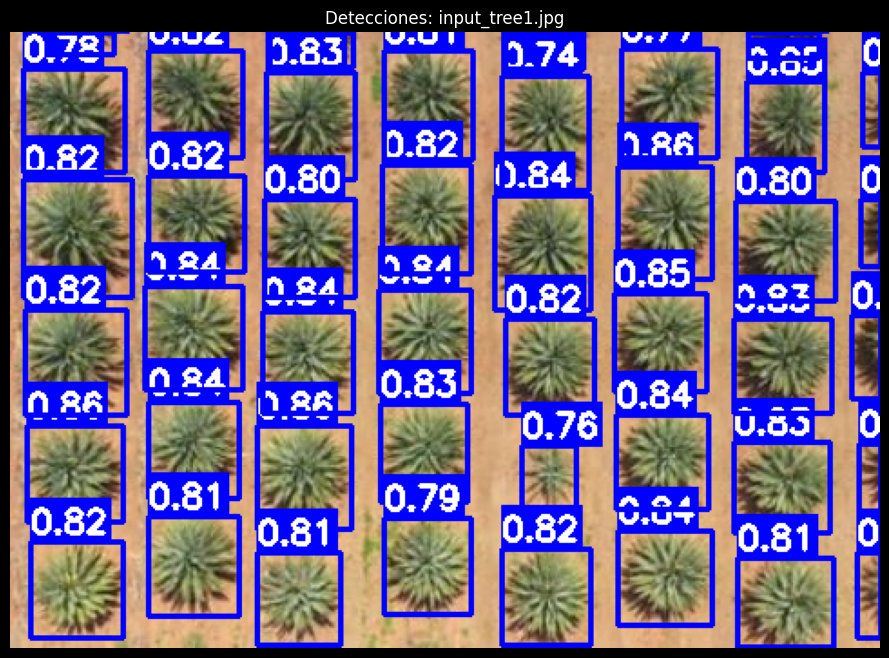

Detecciones por niveles de confianza:
nivel_confianza
Muy Alta (70%+)    35
Alta (50-70%)       7
Media (30-50%)      2
Baja (0-30%)        0
Name: count, dtype: int64

Imagen: input_tree2.jpg
Detecciones totales: 142
Confianza promedio: 0.367
Confianza máxima: 0.694
Confianza mínima: 0.227


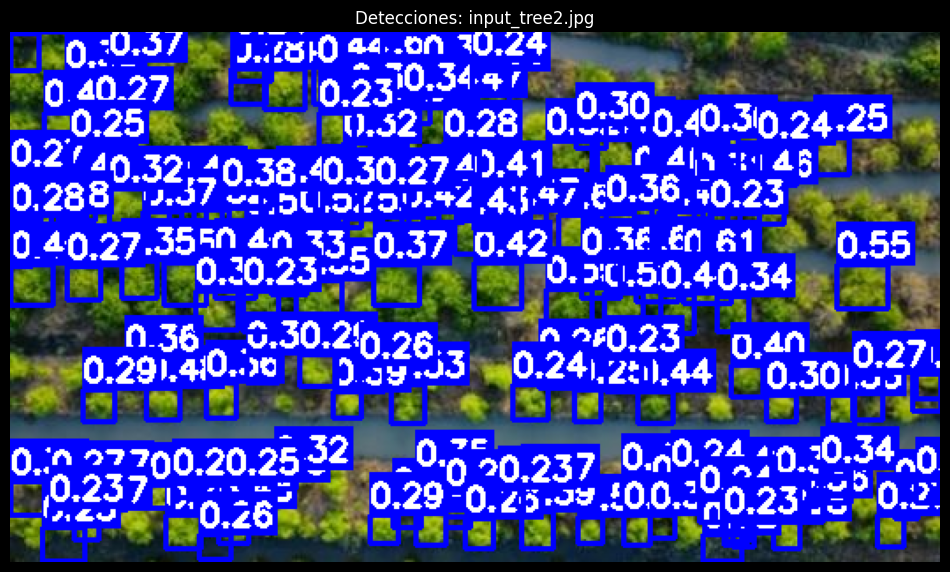

Detecciones por niveles de confianza:
nivel_confianza
Media (30-50%)     80
Baja (0-30%)       46
Alta (50-70%)      16
Muy Alta (70%+)     0
Name: count, dtype: int64

Imagen: input_tree3.jpg
Detecciones totales: 37
Confianza promedio: 0.539
Confianza máxima: 0.792
Confianza mínima: 0.228


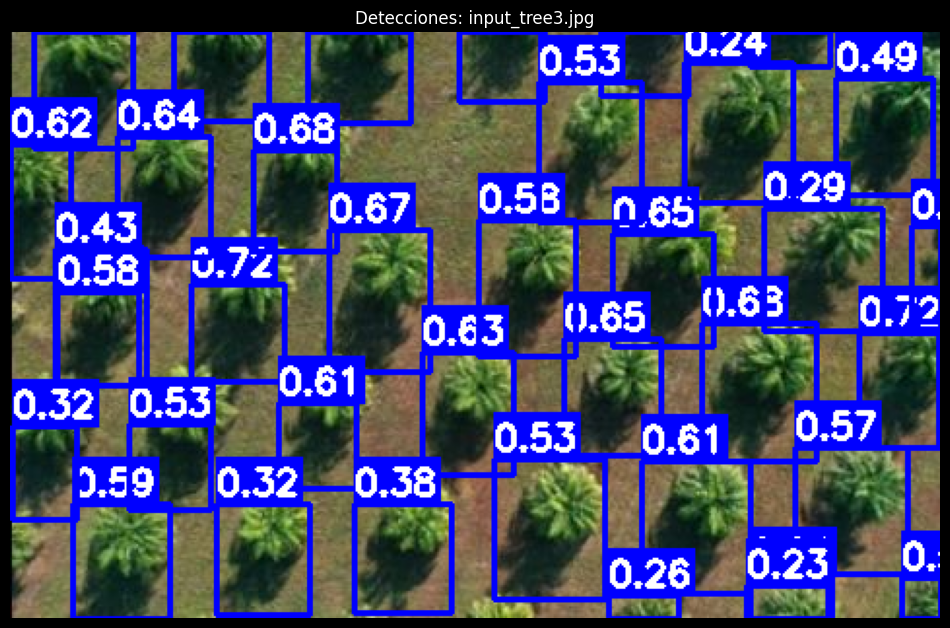

Detecciones por niveles de confianza:
nivel_confianza
Alta (50-70%)      20
Baja (0-30%)        6
Media (30-50%)      6
Muy Alta (70%+)     5
Name: count, dtype: int64

--- REPORTE FINAL ---
Total detecciones: 223
Confianza promedio: 0.474

Detecciones por imagen:
                 count   mean    max
imagen                              
input_tree1.jpg     44  0.766  0.865
input_tree2.jpg    142  0.367  0.694
input_tree3.jpg     37  0.539  0.792


In [14]:
# 8. BUSCAR Y PROBAR MODELO - UMBRAL ALTO

# Buscar en directorio
imagenes_disponibles = [
    f for f in os.listdir(".") if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
]

# Parámetros configurables
UMBRAL_MINIMO = 0.225  # confianza minima de deteccion

# Si existen imagenes hacemos inferencias
if imagenes_disponibles:
    print(f"Encontradas {len(imagenes_disponibles)} imágenes:")
    for img in imagenes_disponibles:
        print(f"  - {img}")

    print(f"\nProcesando con umbral mínimo: {UMBRAL_MINIMO}")

    resultados_finales = []

    for img in imagenes_disponibles:
        df_resultado = detectar_objetos(
            img, umbral_confianza=UMBRAL_MINIMO, mostrar=True
        )

        if df_resultado is not None and len(df_resultado) > 0:
            resultados_finales.append(df_resultado)

            # Mostrar estadísticas
            print("Detecciones por niveles de confianza:")
            bins = [0, 0.3, 0.5, 0.7, 1.0]
            labels = [
                "Baja (0-30%)",
                "Media (30-50%)",
                "Alta (50-70%)",
                "Muy Alta (70%+)",
            ]
            df_resultado["nivel_confianza"] = pd.cut(
                df_resultado["confianza"], bins=bins, labels=labels
            )
            print(df_resultado["nivel_confianza"].value_counts())

    # DataFrame final consolidado
    if resultados_finales:
        df_final = pd.concat(resultados_finales, ignore_index=True)
        print(f"\n--- REPORTE FINAL ---")
        print(f"Total detecciones: {len(df_final)}")
        print(f"Confianza promedio: {df_final['confianza'].mean():.3f}")
        print("\nDetecciones por imagen:")
        print(
            df_final.groupby("imagen")["confianza"]
            .agg(["count", "mean", "max"])
            .round(3)
        )

____

Referencias y Agradecimientos

- Roboflow por proporcionar una plataforma accesible para la gestión de datasets de visión computacional
- Ultralytics y los desarrolladores de YOLOv11 por mantener y desarrollar herramientas open-source de alta calidad
- Los creadores de YOLOv12 por sus contribuciones a la investigación en detección de objetos
- La comunidad open-source que hace posible el acceso a estas tecnologías para propósitos educativos

```bibtex
@article{tian2025yolov12,
  title={YOLOv12: Attention-Centric Real-Time Object Detectors},
  author={Tian, Yunjie and Ye, Qixiang and Doermann, David},
  journal={arXiv preprint arXiv:2502.12524},
  year={2025}
}
```

```bibtex
@software{yolo11_ultralytics,
  author = {Glenn Jocher and Jing Qiu},
  title = {Ultralytics YOLO11},
  version = {11.0.0},
  year = {2024},
  url = {https://github.com/ultralytics/ultralytics},
  license = {AGPL-3.0}
}
```

```bibtex
@software{roboflow,
  author = {Dwyer, B. and Nelson, J. and Hansen, T. and others},
  title = {Roboflow},
  version = {1.0},
  year = {2025},
  url = {https://roboflow.com}
}
```